🎉 데이터 가져오기 성공!
           날짜    검색량_비율
0  2019-01-01  62.68524
1  2019-02-01  53.26816
2  2019-03-01  63.80323
3  2019-04-01  76.50668
4  2019-05-01  74.88430
..        ...       ...
80 2025-09-01  63.67843
81 2025-10-01  55.12453
82 2025-11-01  68.67037
83 2025-12-01  69.46596
84 2026-01-01  54.53174

[85 rows x 2 columns]
💾 성공적으로 파일이 저장되었습니다! 파일명: 건강기능식픔KW.csv


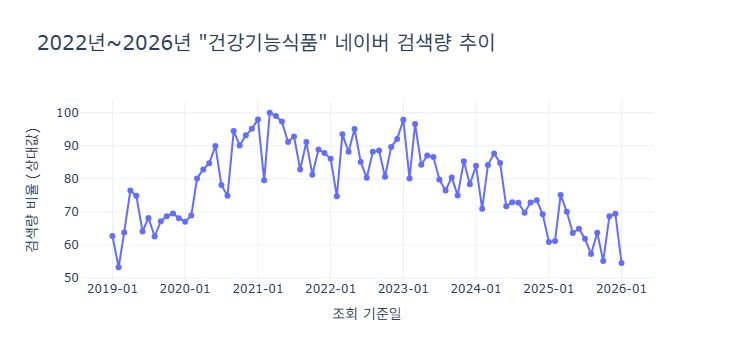

In [18]:
#KW: 건강기능 식품

import json
import requests
import pandas as pd
import plotly.express as px

# 1. 네이버 개발자 센터에서 발급받은 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
CLIENT_SECRET = "7MP3lY3dzz" # 이미지 속 Client Secret 입력 # 여기에 발급받은 Client Secret을 넣으세요

# 2. API 엔드포인트 설정
url = "https://openapi.naver.com/v1/datalab/search"

# 3. 요청 헤더 설정
headers = {
    "X-Naver-Client-Id": CLIENT_ID,
    "X-Naver-Client-Secret": CLIENT_SECRET,
    "Content-Type": "application/json"
}

# 4. 요청 파라미터 (2023년 ~ 2026년 데이터 설정)
body = {
    "startDate": "2019-01-01",
    "endDate": "2026-01-01",          # 2026년 현재 시점 반영
    "timeUnit": "month",               # 추이를 보기 쉽게 '월간'으로 설정
    "keywordGroups": [
        {
            "groupName": "건강기능식품",
            "keywords": ["건강기능식품"]
        }
    ]
}

# 5. API 요청 보내기
response = requests.post(url, headers=headers, data=json.dumps(body))

# 6. 데이터 가공 및 Plotly 시각화
if response.status_code == 200:
    res_json = response.json()
    
    # 결과 데이터에서 날짜와 비율(검색량) 추출
    data_list = res_json['results'][0]['data']
    
    # 판다스 데이터프레임으로 변환
    df = pd.DataFrame(data_list)
    df.columns = ['날짜', '검색량_비율']
    
    # Plotly가 날짜 축을 올바르게 인식하도록 데이터 타입 변환
    df['날짜'] = pd.to_datetime(df['날짜'])
    
    print("🎉 데이터 가져오기 성공!")
    print(df) # 상위 5개 데이터 미리보기

    # 🚨 본인의 데이터프레임 변수명에 맞게 설정하세요 (예: df_search, df_trend 등)
    target_df = df  
    
    # 지정된 규칙과 조건에 맞춘 CSV 저장 코드
    output_filename = "건강기능식픔KW.csv" # 필요시 파일명 변경 가능
    target_df.to_csv(output_filename, index=False, encoding="utf-8-sig")

    print(f"💾 성공적으로 파일이 저장되었습니다! 파일명: {output_filename}")
    
    # 7. Plotly를 이용한 인터랙티브 라인 차트 생성
    fig = px.line(
        df, 
        x='날짜', 
        y='검색량_비율', 
        title='2022년~2026년 "건강기능식품" 네이버 검색량 추이',
        labels={'날짜': '조회 기준일', '검색량_비율': '검색량 비율 (상대값)'},
        markers=True # 데이터 포인트마다 점 표시
    )
    
    # 그래프 스타일 및 레이아웃 미세 조정
    fig.update_layout(
        title_font_size=20,
        xaxis_tickformat='%Y-%m', # X축 날짜 형식을 '년-월'로 지정
        template='plotly_white',  # 깔끔한 흰색 배경 테마
        hovermode='x unified'     # 마우스를 올렸을 때 해당 시점의 데이터 팝업 강조
    )
    
    # Jupyter Notebook에 그래프 출력
    fig.show()

else:
    print(f"❌ API 요청 실패 (에러 코드: {response.status_code})")
    print(response.text)

   
    

🎉 데이터 가져오기 성공!
           날짜     검색량_비율
0  2022-02-01    2.13675
1  2022-03-01    2.56410
2  2022-04-01    2.99145
3  2022-05-01    4.48717
4  2022-06-01    4.70085
5  2022-07-01    2.13675
6  2022-08-01    2.35042
7  2022-09-01    6.62393
8  2022-10-01    3.63247
9  2022-11-01    8.33333
10 2022-12-01    2.35042
11 2023-01-01    3.84615
12 2023-02-01    3.63247
13 2023-03-01    2.56410
14 2023-04-01    5.12820
15 2023-05-01   13.24786
16 2023-06-01   15.17094
17 2023-07-01   12.39316
18 2023-08-01    6.41025
19 2023-09-01   15.81196
20 2023-10-01   11.11111
21 2023-11-01    7.05128
22 2023-12-01    6.62393
23 2024-01-01   11.32478
24 2024-02-01   20.72649
25 2024-03-01   31.83760
26 2024-04-01   38.46153
27 2024-05-01   36.96581
28 2024-06-01   38.67521
29 2024-07-01   42.73504
30 2024-08-01   46.36752
31 2024-09-01   62.17948
32 2024-10-01   65.81196
33 2024-11-01   52.99145
34 2024-12-01   47.86324
35 2025-01-01   44.44444
36 2025-02-01   52.77777
37 2025-03-01   85.89743
38 2025-04

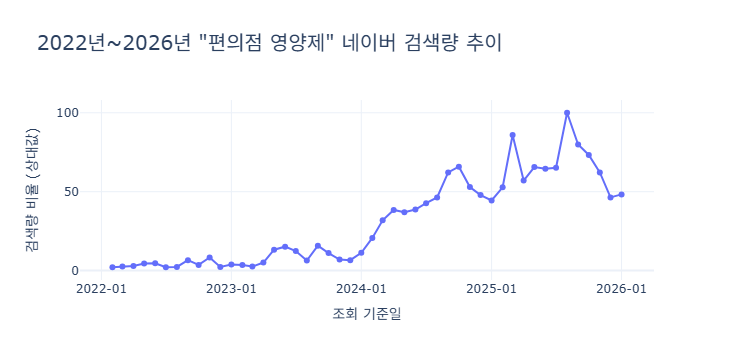

In [20]:
#KW: 편의점 영양제

import json
import requests
import pandas as pd
import plotly.express as px

# 1. 네이버 개발자 센터에서 발급받은 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
CLIENT_SECRET = "7MP3lY3dzz" # 이미지 속 Client Secret 입력 # 여기에 발급받은 Client Secret을 넣으세요

# 2. API 엔드포인트 설정
url = "https://openapi.naver.com/v1/datalab/search"

# 3. 요청 헤더 설정
headers = {
    "X-Naver-Client-Id": CLIENT_ID,
    "X-Naver-Client-Secret": CLIENT_SECRET,
    "Content-Type": "application/json"
}

# 4. 요청 파라미터 (2023년 ~ 2026년 데이터 설정)
body = {
    "startDate": "2022-01-01",
    "endDate": "2026-01-01",          # 2026년 현재 시점 반영
    "timeUnit": "month",               # 추이를 보기 쉽게 '월간'으로 설정
    "keywordGroups": [
        {
            "groupName": "편의점 영양제",
            "keywords": ["편의점 영양제"]
        }
    ]
}

# 5. API 요청 보내기
response = requests.post(url, headers=headers, data=json.dumps(body))

# 6. 데이터 가공 및 Plotly 시각화
if response.status_code == 200:
    res_json = response.json()
    
    # 결과 데이터에서 날짜와 비율(검색량) 추출
    data_list = res_json['results'][0]['data']
    
    # 판다스 데이터프레임으로 변환
    df = pd.DataFrame(data_list)
    df.columns = ['날짜', '검색량_비율']
    
    # Plotly가 날짜 축을 올바르게 인식하도록 데이터 타입 변환
    df['날짜'] = pd.to_datetime(df['날짜'])
    
    print("🎉 데이터 가져오기 성공!")
    print(df) # 상위 5개 데이터 미리보기

    # 🚨 본인의 데이터프레임 변수명에 맞게 설정하세요 (예: df_search, df_trend 등)
    target_df = df
    
    # 지정된 규칙과 조건에 맞춘 CSV 저장 코드
    output_filename = "편의점영양제KW.csv" # 필요시 파일명 변경 가능
    target_df.to_csv(output_filename, index=False, encoding="utf-8-sig")
    
    print(f"💾 성공적으로 파일이 저장되었습니다! 파일명: {output_filename}")
        
    # 7. Plotly를 이용한 인터랙티브 라인 차트 생성
    fig = px.line(
        df, 
        x='날짜', 
        y='검색량_비율', 
        title='2022년~2026년 "편의점 영양제" 네이버 검색량 추이',
        labels={'날짜': '조회 기준일', '검색량_비율': '검색량 비율 (상대값)'},
        markers=True # 데이터 포인트마다 점 표시
    )
    
    # 그래프 스타일 및 레이아웃 미세 조정
    fig.update_layout(
        title_font_size=20,
        xaxis_tickformat='%Y-%m', # X축 날짜 형식을 '년-월'로 지정
        template='plotly_white',  # 깔끔한 흰색 배경 테마
        hovermode='x unified'     # 마우스를 올렸을 때 해당 시점의 데이터 팝업 강조
    )
    
    # Jupyter Notebook에 그래프 출력
    fig.show()

else:
    print(f"❌ API 요청 실패 (에러 코드: {response.status_code})")
    print(response.text)

🎉 데이터 가져오기 성공!
           날짜    검색량_비율
0  2019-01-01  16.66666
1  2019-08-01  16.66666
2  2019-09-01  13.88888
3  2019-10-01  47.22222
4  2019-11-01  61.11111
..        ...       ...
67 2025-05-01  33.33333
68 2025-08-01  27.77777
69 2025-09-01  41.66666
70 2025-10-01  13.88888
71 2025-11-01  13.88888

[72 rows x 2 columns]
💾 성공적으로 파일이 저장되었습니다! 파일명: 가성비영양제KW.csv


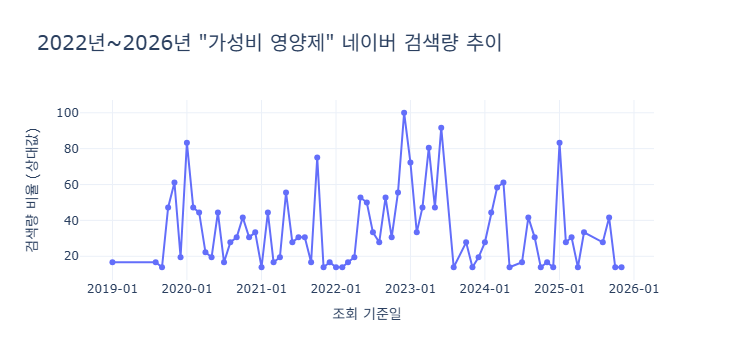

In [19]:
#KW: 가성비 영양제

import json
import requests
import pandas as pd
import plotly.express as px

# 1. 네이버 개발자 센터에서 발급받은 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
CLIENT_SECRET = "7MP3lY3dzz" # 이미지 속 Client Secret 입력 # 여기에 발급받은 Client Secret을 넣으세요

# 2. API 엔드포인트 설정
url = "https://openapi.naver.com/v1/datalab/search"

# 3. 요청 헤더 설정
headers = {
    "X-Naver-Client-Id": CLIENT_ID,
    "X-Naver-Client-Secret": CLIENT_SECRET,
    "Content-Type": "application/json"
}

# 4. 요청 파라미터 (2023년 ~ 2026년 데이터 설정)
body = {
    "startDate": "2019-01-01",
    "endDate": "2026-01-01",          # 2026년 현재 시점 반영
    "timeUnit": "month",               # 추이를 보기 쉽게 '월간'으로 설정
    "keywordGroups": [
        {
            "groupName": "가성비 영양제",
            "keywords": ["가성비 영양제"]
        }
    ]
}

# 5. API 요청 보내기
response = requests.post(url, headers=headers, data=json.dumps(body))

# 6. 데이터 가공 및 Plotly 시각화
if response.status_code == 200:
    res_json = response.json()
    
    # 결과 데이터에서 날짜와 비율(검색량) 추출
    data_list = res_json['results'][0]['data']
    
    # 판다스 데이터프레임으로 변환
    df = pd.DataFrame(data_list)
    df.columns = ['날짜', '검색량_비율']
    
    # Plotly가 날짜 축을 올바르게 인식하도록 데이터 타입 변환
    df['날짜'] = pd.to_datetime(df['날짜'])
    
    print("🎉 데이터 가져오기 성공!")
    print(df) # 상위 5개 데이터 미리보기

    # 🚨 본인의 데이터프레임 변수명에 맞게 설정하세요 (예: df_search, df_trend 등)
    target_df = df 
    
    # 지정된 규칙과 조건에 맞춘 CSV 저장 코드
    output_filename = "가성비영양제KW.csv" # 필요시 파일명 변경 가능
    target_df.to_csv(output_filename, index=False, encoding="utf-8-sig")
    
    print(f"💾 성공적으로 파일이 저장되었습니다! 파일명: {output_filename}")
    
    # 7. Plotly를 이용한 인터랙티브 라인 차트 생성
    fig = px.line(
        df, 
        x='날짜', 
        y='검색량_비율', 
        title='2022년~2026년 "가성비 영양제" 네이버 검색량 추이',
        labels={'날짜': '조회 기준일', '검색량_비율': '검색량 비율 (상대값)'},
        markers=True # 데이터 포인트마다 점 표시
    )
    
    # 그래프 스타일 및 레이아웃 미세 조정
    fig.update_layout(
        title_font_size=20,
        xaxis_tickformat='%Y-%m', # X축 날짜 형식을 '년-월'로 지정
        template='plotly_white',  # 깔끔한 흰색 배경 테마
        hovermode='x unified'     # 마우스를 올렸을 때 해당 시점의 데이터 팝업 강조
    )
    
    # Jupyter Notebook에 그래프 출력
    fig.show()

else:
    print(f"❌ API 요청 실패 (에러 코드: {response.status_code})")
    print(response.text)

🎉 데이터 가져오기 성공!
           날짜    검색량_비율
0  2019-01-01  30.98039
1  2019-02-01  23.33333
2  2019-03-01  31.56862
3  2019-04-01  28.23529
4  2019-05-01  43.13725
..        ...       ...
80 2025-09-01  19.80392
81 2025-10-01  17.45098
82 2025-11-01  10.58823
83 2025-12-01  20.78431
84 2026-01-01  24.31372

[85 rows x 2 columns]


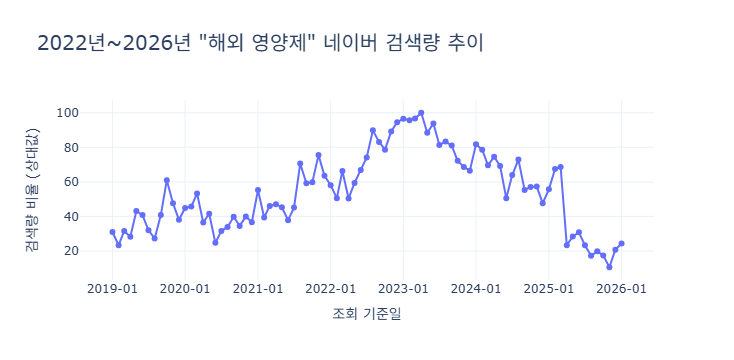

In [13]:
#KW: 해외영양제

import json
import requests
import pandas as pd
import plotly.express as px

# 1. 네이버 개발자 센터에서 발급받은 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
CLIENT_SECRET = "7MP3lY3dzz" # 이미지 속 Client Secret 입력 # 여기에 발급받은 Client Secret을 넣으세요

# 2. API 엔드포인트 설정
url = "https://openapi.naver.com/v1/datalab/search"

# 3. 요청 헤더 설정
headers = {
    "X-Naver-Client-Id": CLIENT_ID,
    "X-Naver-Client-Secret": CLIENT_SECRET,
    "Content-Type": "application/json"
}

# 4. 요청 파라미터 (2023년 ~ 2026년 데이터 설정)
body = {
    "startDate": "2019-01-01",
    "endDate": "2026-01-01",          # 2026년 현재 시점 반영
    "timeUnit": "month",               # 추이를 보기 쉽게 '월간'으로 설정
    "keywordGroups": [
        {
            "groupName": "해외 영양제",
            "keywords": ["해외 영양제"]
        }
    ]
}

# 5. API 요청 보내기
response = requests.post(url, headers=headers, data=json.dumps(body))

# 6. 데이터 가공 및 Plotly 시각화
if response.status_code == 200:
    res_json = response.json()
    
    # 결과 데이터에서 날짜와 비율(검색량) 추출
    data_list = res_json['results'][0]['data']
    
    # 판다스 데이터프레임으로 변환
    df = pd.DataFrame(data_list)
    df.columns = ['날짜', '검색량_비율']
    
    # Plotly가 날짜 축을 올바르게 인식하도록 데이터 타입 변환
    df['날짜'] = pd.to_datetime(df['날짜'])
    
    print("🎉 데이터 가져오기 성공!")
    print(df) # 상위 5개 데이터 미리보기
    
    # 7. Plotly를 이용한 인터랙티브 라인 차트 생성
    fig = px.line(
        df, 
        x='날짜', 
        y='검색량_비율', 
        title='2022년~2026년 "해외 영양제" 네이버 검색량 추이',
        labels={'날짜': '조회 기준일', '검색량_비율': '검색량 비율 (상대값)'},
        markers=True # 데이터 포인트마다 점 표시
    )
    
    # 그래프 스타일 및 레이아웃 미세 조정
    fig.update_layout(
        title_font_size=20,
        xaxis_tickformat='%Y-%m', # X축 날짜 형식을 '년-월'로 지정
        template='plotly_white',  # 깔끔한 흰색 배경 테마
        hovermode='x unified'     # 마우스를 올렸을 때 해당 시점의 데이터 팝업 강조
    )
    
    # Jupyter Notebook에 그래프 출력
    fig.show()

else:
    print(f"❌ API 요청 실패 (에러 코드: {response.status_code})")
    print(response.text)

🎉 데이터 가져오기 성공!
           날짜     검색량_비율
0  2022-01-01   85.03965
1  2022-02-01   62.79740
2  2022-03-01   88.08579
3  2022-04-01   79.21773
4  2022-05-01   78.82119
5  2022-06-01   63.62653
6  2022-07-01   50.52271
7  2022-08-01   53.55082
8  2022-09-01   69.50252
9  2022-10-01   72.98125
10 2022-11-01   60.11175
11 2022-12-01   51.40591
12 2023-01-01   39.56380
13 2023-02-01   47.13410
14 2023-03-01   59.87743
15 2023-04-01   57.51622
16 2023-05-01   65.98774
17 2023-06-01   57.02956
18 2023-07-01   51.08147
19 2023-08-01   44.19610
20 2023-09-01  100.00000
21 2023-10-01   70.11535
22 2023-11-01   58.57966
23 2023-12-01   32.01153
24 2024-01-01   57.91276
25 2024-02-01   38.87887
26 2024-03-01   52.32516
27 2024-04-01   46.39509
28 2024-05-01   59.78731
29 2024-06-01   48.79235
30 2024-07-01   48.64816
31 2024-08-01   46.48521
32 2024-09-01   49.47728
33 2024-10-01   50.82912
34 2024-11-01   48.93655
35 2024-12-01   27.90194
36 2025-01-01   23.35976
37 2025-02-01   27.36121
38 2025-03

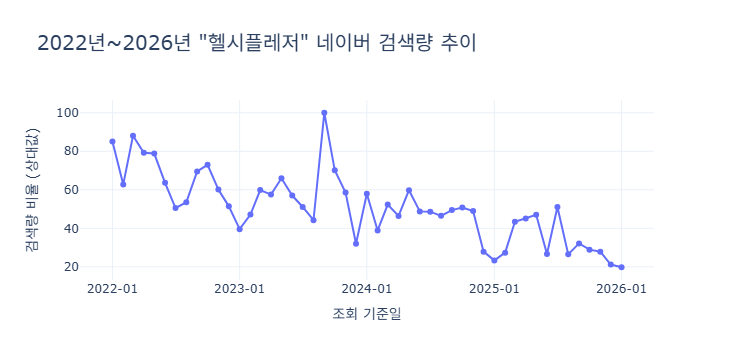

In [4]:
import json
import requests
import pandas as pd
import plotly.express as px

# 1. 네이버 개발자 센터에서 발급받은 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
CLIENT_SECRET = "7MP3lY3dzz" # 이미지 속 Client Secret 입력 # 여기에 발급받은 Client Secret을 넣으세요

# 2. API 엔드포인트 설정
url = "https://openapi.naver.com/v1/datalab/search"

# 3. 요청 헤더 설정
headers = {
    "X-Naver-Client-Id": CLIENT_ID,
    "X-Naver-Client-Secret": CLIENT_SECRET,
    "Content-Type": "application/json"
}

# 4. 요청 파라미터 (2023년 ~ 2026년 데이터 설정)
body = {
    "startDate": "2022-01-01",
    "endDate": "2026-01-01",          # 2026년 현재 시점 반영
    "timeUnit": "month",               # 추이를 보기 쉽게 '월간'으로 설정
    "keywordGroups": [
        {
            "groupName": "헬시플레저",
            "keywords": ["헬시플레저"]
        }
    ]
}

# 5. API 요청 보내기
response = requests.post(url, headers=headers, data=json.dumps(body))

# 6. 데이터 가공 및 Plotly 시각화
if response.status_code == 200:
    res_json = response.json()
    
    # 결과 데이터에서 날짜와 비율(검색량) 추출
    data_list = res_json['results'][0]['data']
    
    # 판다스 데이터프레임으로 변환
    df = pd.DataFrame(data_list)
    df.columns = ['날짜', '검색량_비율']
    
    # Plotly가 날짜 축을 올바르게 인식하도록 데이터 타입 변환
    df['날짜'] = pd.to_datetime(df['날짜'])
    
    print("🎉 데이터 가져오기 성공!")
    print(df) # 상위 5개 데이터 미리보기
    
    # 7. Plotly를 이용한 인터랙티브 라인 차트 생성
    fig = px.line(
        df, 
        x='날짜', 
        y='검색량_비율', 
        title='2022년~2026년 "헬시플레저" 네이버 검색량 추이',
        labels={'날짜': '조회 기준일', '검색량_비율': '검색량 비율 (상대값)'},
        markers=True # 데이터 포인트마다 점 표시
    )
    
    # 그래프 스타일 및 레이아웃 미세 조정
    fig.update_layout(
        title_font_size=20,
        xaxis_tickformat='%Y-%m', # X축 날짜 형식을 '년-월'로 지정
        template='plotly_white',  # 깔끔한 흰색 배경 테마
        hovermode='x unified'     # 마우스를 올렸을 때 해당 시점의 데이터 팝업 강조
    )
    
    # Jupyter Notebook에 그래프 출력
    fig.show()

else:
    print(f"❌ API 요청 실패 (에러 코드: {response.status_code})")
    print(response.text)

In [11]:
import urllib.parse
import requests
import pandas as pd

# 1. 네이버 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
CLIENT_SECRET = "7MP3lY3dzz"

# 2. 검색 설정
keyword = "cu 영양제"
display_count = 50  # 블로그, 카페에서 각각 가져올 글의 개수 (최대 100)

# 검색어를 URL 인코딩
encoded_keyword = urllib.parse.quote(keyword)

# 3. 네이버 검색 API 호출 함수 정의
def get_naver_search(target_type, query, display):
    """
    target_type: 'blog' 또는 'cafearticle'
    """
    url = f"https://openapi.naver.com/v1/search/{target_type}.json?query={query}&display={display}&sort=sim"
    
    headers = {
        "X-Naver-Client-Id": CLIENT_ID,
        "X-Naver-Client-Secret": CLIENT_SECRET
    }
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        items = response.json().get('items', [])
        data = []
        for item in items:
            # HTML 태그 제거 및 텍스트 정제
            title = item['title'].replace('<b>', '').replace('</b>', '')
            description = item['description'].replace('<b>', '').replace('</b>', '')
            
            data.append({
                "출처": "블로그" if target_type == "blog" else "카페",
                "제목": title,
                "요약내용": description,
                "링크": item['link']
            })
        return data
    else:
        print(f"❌ {target_type} API 요청 실패: {response.status_code}")
        return []

# 4. 블로그와 카페에서 각각 데이터 수집
print("🔄 네이버 블로그 글 수집 중...")
blog_results = get_naver_search("blog", encoded_keyword, display_count)

print("🔄 네이버 카페 글 수집 중...")
cafe_results = get_naver_search("cafearticle", encoded_keyword, display_count)

# 5. 데이터 통합 및 판다스 데이터프레임 변환
total_results = blog_results + cafe_results

if total_results:
    df_search = pd.DataFrame(total_results)
    print(f"\n🎉 수집 완료! 총 {len(df_search)}개의 글을 수집했습니다.")
    
    # Jupyter Notebook에서 데이터프레임 출력
    # 행이 잘리지 않고 다 보이도록 설정 후 출력
    pd.set_option('display.max_colwidth', None)
    display(df_search.head(30)) # 상위 10개 출력
else:
    print("수집된 데이터가 없습니다. API 키나 키워드를 확인해 주세요.")

🔄 네이버 블로그 글 수집 중...
🔄 네이버 카페 글 수집 중...

🎉 수집 완료! 총 100개의 글을 수집했습니다.


,출처,제목,요약내용,링크
0,블로그,동네 CU 편의점 알바생도 놀란 26년 5월 영양제 90% 할인...,[첫 번째: CU 영양제 90% 할인의 치명적인 함정] 이번 5월 행사의 핵심은 무조건 CU에서 파는... 저는 내일 아침 출근길에도 일찍 CU에 들러서 동네에 남은 영양제 싹쓸이 좀 해보려고요. 다치지 않고 무사히...,https://blog.naver.com/doublepapa/224271893458
1,블로그,cu영양제 비컴플 아르기닌 마그네슘,"cu로부터 제품을 제공받아 쓴 솔직리뷰입니다. 요즘 스트레스로 인한 피로가 누적되면서 가벼운... 사용할 예정이며, 건강 관리가 필요한 분들에게 적극 추천합니다. #cu영양제 #편의점영양제 #비컴플 #비컴플영양제",https://blog.naver.com/eheh1123-/223666546351
2,블로그,cu 토스 영양제 행사 씨유 동아제약 셀파렉스 영양제 정보,cu 토스 영양제 행사해서 사왔는데요 씨유 동아제약 샐파렉스 영양제 정보 입니다 뭔가 포스팅... 영양제 정보였습니다 ⬇️ 할인정보는 요기 #씨유 #영양제 #씨유영양제 #씨유양양제할인 #cu영양제할인...,https://blog.naver.com/llsopiall/224278636896
3,블로그,CU 영양제 토스페이머니 130알 3900원 구매후기,"오늘은 CU 영양제 구입 행사로 영양제 130알을 3,900원에 구입한 후기 남겨볼게요. 아래 결제... CU 앱, 토스페이머니 (필수 O) 상위 링크가 이벤트 페이지고요! 아래서 캡처 본으로 보여드릴게요. 5월 내내...",https://blog.naver.com/koya0205/224279168145
4,블로그,cu 영양제 90% 할인받아 500원에 구매 성공 내돈내산,"일단 cu에서 어떤 이벤트 진행 중인지 알려드릴게요! 영양제 종류도 다양해요! 동생 5개, 저 5개 구매해 봤습니다. 유통기한도 제일 긴 게 27년 8월 19일 ~ 제일 짧은 게 27년 7월 8일 충분하죠 ? 동생은 다이어트...",https://blog.naver.com/eunhye-_-99/224276364879
5,블로그,CU 편의점 다이어트 영양제 &lt;종근당 건강프로젝트365...,그래서 쉽고 간편하게 접근성이 쉬운 CU 편의점 다이어트 영양제를 구입했어요! 12월은 1+1 이벤트... CU 영양제로 체중감량 꼭 성공해서 2026년은 늘씬해질 수 있기를 바라고 있어요. 종근당에서 만든 제품이니까...,https://blog.naver.com/mima44/224118683482
6,블로그,다리 붓기 고민하다 발견한 CU편의점 가성비 영양제,"그래서 영양제를 챙겨 먹어야겠다고 생각하던 중, 우연히 CU편의점에서 영양제를 발견하게 됐습니다.... #CU영양제 #편의점영양제 #가성비영양제 #혈행건강 #뼈건강 #이너케어 #다리붓기 #혈액순환 #건강관리...",https://blog.naver.com/euleul-/224233251512
7,블로그,어버이날 선물 고민 끝 CU 영양제 3900원 득템,용돈이랑 엄빠 갔다드려야지❤️ 저렴하게 영양제 겟하려면 언능 CU달려가세욤!! #짠테크 #편의점꿀템 #CU추천 #종근당 #어버이날선물 #가성비선물 #신혼부부절약 #생활비절약 #소소한행복 #득템,https://blog.naver.com/yeran0702/224275476891
8,블로그,CU 편의점 영양제 비컴플 2종 마그네슘 아르기닌,"CU 편의점 영양제 안녕하세요 오늘 소개해드리는 건 CU 영양제 비컴플 2종입니다. 편의점에서는 먹을 거만 사봤지, 한 번도 영양제를 구매해 본 적이 없는데요. 사실 있는지도 몰랐어요... 그래서 궁금하기도 해서...",https://blog.naver.com/mukningen/223671075521
9,블로그,CU 편의점 5월 행사! 영양제·단백질쉐이크 1+1 &amp; 최대 75...,포켓cu픽업 #포켓cu쿠폰 #cu편의점행사 #cu편의점할인 #cu편의점5월행사 #cu편의점이벤트 #cu영양제... CU편의점행사 #CU5월이벤트 #영양제1+1 #프로틴쉐이크1+1 #편의점세일 #CU할인정보 #다이어트간편식...,https://blog.naver.com/na21100/223861013572


In [14]:
#CU 영양제 블로그 크롤링

import re
import urllib.parse
import requests
import pandas as pd
from datetime import datetime

# 1. 네이버 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" 
CLIENT_SECRET = "7MP3lY3dzz"

# 2. 검색 및 조건 설정
keyword = "cu 건기식"
display_count = 100  # 날짜 조건 필터링을 위해 데이터를 넉넉히 가져옵니다 (최대 100)
target_count = 5     # 최종 수집 목표 개수

# 검색어를 URL 인코딩
encoded_keyword = urllib.parse.quote(keyword)

# 날짜 조건 설정 (2025년 5월 14일 ~ 2026년 5월 15일)
start_date_limit = datetime(2025, 5, 14, 0, 0, 0)
end_date_limit = datetime(2026, 5, 15, 23, 59, 59)


# [추가] 해시태그 및 본문 정제용 헬퍼 함수
def clean_and_extract(description):
    # 1. 줄바꿈(\n, \r) 삭제
    clean_text = description.replace("\n", " ").replace("\r", " ")
    
    # 2. HTML 태그 제거
    clean_text = re.sub(r'<[^>]+>', '', clean_text)
    
    # 3. 해시태그(#텍스트) 추출
    hashtag_list = re.findall(r'#\w+', clean_text)
    
    # 4. 본문에서 해시태그 제거 및 공백 정돈
    caption_text = re.sub(r'#\w+', '', clean_text).strip()
    caption_text = re.sub(r'\s+', ' ', caption_text)
    
    # 5. 해시태그 규칙: 쉼표 구분, 없으면 ""
    hashtags = ",".join(hashtag_list) if hashtag_list else ""
    
    return caption_text, hashtags


# 3. 네이버 검색 API 호출 함수 정의 (기존 구조 유지 + 규칙 반영)
def get_naver_search(target_type, query, display):
    """
    target_type: 'blog' 또는 'cafearticle'
    """
    # 최신 날짜 순으로 필터링하기 위해 sort=date로 적용합니다
    url = f"https://openapi.naver.com/v1/search/{target_type}.json?query={query}&display={display}&sort=date"
    
    headers = {
        "X-Naver-Client-Id": CLIENT_ID,
        "X-Naver-Client-Secret": CLIENT_SECRET
    }
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        items = response.json().get('items', [])
        data = []
        for item in items:
            # 🚨 날짜 파싱 및 범위 조건 검증
            try:
                if target_type == "blog":
                    post_datetime = datetime.strptime(item['postdate'], "%Y%m%d")
                else:
                    post_datetime = pd.to_datetime(item.get('postdate', datetime.now())).to_pydatetime()
            except:
                continue
            
            # 지정된 날짜 범위를 벗어나면 제외
            if not (start_date_limit <= post_datetime <= end_date_limit):
                continue
            
            # HTML 태그 제거 및 규칙에 따른 텍스트 정제
            title = item['title'].replace('<b>', '').replace('</b>', '')
            caption_text, hashtags = clean_and_extract(item['description'])
            
            # 🚨 요구사항에 맞춘 컬럼 구조 및 타입 매칭
            data.append({
                "brand_name": "CU",
                "platform_name": "네이버",
                "title": title,
                "caption_text": caption_text,
                "hashtags": hashtags,
                "like_count": 0,       # API 제공 불가로 0 처리
                "view_count": 0,       # API 제공 불가로 0 처리
                "comment_count": 0,    # API 제공 불가로 0 처리
                "upload_date": post_datetime.strftime("%Y-%m-%d %H:%M:%S"), # 지정된 포맷
                "content_url": item['link']
            })
        return data
    else:
        print(f"❌ {target_type} API 요청 실패: {response.status_code}")
        return []

# 4. 블로그와 카페에서 각각 데이터 수집
print("🔄 네이버 블로그 글 수집 중...")
blog_results = get_naver_search("blog", encoded_keyword, display_count)

print("🔄 네이버 카페 글 수집 중...")
cafe_results = get_naver_search("cafearticle", encoded_keyword, display_count)

# 5. 데이터 통합 및 판다스 데이터프레임 변환
total_results = blog_results + cafe_results

if total_results:
    # 🚨 최신순 조건 기준 상위 5개만 최종 슬라이싱
    final_results = total_results[:target_count]
    
    df_search = pd.DataFrame(final_results)
    print(f"\n🎉 조건 만족 데이터 정제 완료! 총 {len(df_search)}개의 최신 글을 지정된 스키마로 구성했습니다.")
    
    # 🚨 조건: 결과를 CSV 파일로 지정된 이름과 인코딩으로 저장
    output_filename = "naver_cu_review.csv"
    df_search.to_csv(output_filename, index=False, encoding="utf-8-sig")
    print(f"💾 '{output_filename}' 파일 저장 성공!")
    
    # Jupyter Notebook에서 데이터프레임 출력
    pd.set_option('display.max_colwidth', None)
    display(df_search) 
else:
    print("⚠️ 지정된 날짜 범위 내에 조건에 맞는 데이터가 존재하지 않습니다.")

🔄 네이버 블로그 글 수집 중...
🔄 네이버 카페 글 수집 중...

🎉 조건 만족 데이터 정제 완료! 총 5개의 최신 글을 지정된 스키마로 구성했습니다.
💾 'naver_cu_review.csv' 파일 저장 성공!


,brand_name,platform_name,title,caption_text,hashtags,like_count,view_count,comment_count,upload_date,content_url
0,CU,네이버,외국인들 건기식·단백질쉐이크 올리브영·CU에서...,"최근 명동과 홍대, 성수동에서 외국인 관광객들이 한국 건기식과 단백질 쉐이크를 대량 구매를 많이하고 있다고합니다. 특히 올리브영과 편의점 CU를 중심으로 “한국 웰니스 제품” 열풍이 커지고 있는데요....",,0,0,0,2026-05-15 00:00:00,https://blog.naver.com/loveran3/224286881724
1,CU,네이버,[CU X 토스페이] 오늘 마지막!! 건강기능식품 90% 할인!...,"동일 제조사 상품으로 5개 이상 포켓CU 어플 내 QR코드 스캔 후 -&gt; 토스페이 머니/계좌로 구매 시 50정에 2,500원이니 완전 꿀이벤트! T멤버십 있는 분들은 T멤버십 CU할인도 같이 받으세요! T멤버십 등급에...",,0,0,0,2026-05-15 00:00:00,https://blog.naver.com/hppy100/224286596151
2,CU,네이버,[CU] 건기식 17종 토스 90% 할인(+skT할인) #건강기능식품...,"[CU] 건기식 17종 토스 90% 할인(+skT할인적용) [CU] 건강기능식품 17종 토스 90%할인 대상일자 : 5/1, 5/5, 5/8, 5/15 오늘 90%마지막 행사일이에요! 일1회, 1회최대 20,000원하도 포켓 cu스캔 후 대상결제수단 결제...",,0,0,0,2026-05-15 00:00:00,https://blog.naver.com/gii1234/224286297941
3,CU,네이버,Weekly Logistics News Letter Vol.789(5/15),"l [CU 물류 파업, 그 후]③보상 타결 BGF, 진짜 복병은 '운송비' l [CU 물류 파업, 그 후]④일회성 비용... &quot;물류 현장 혁신 이끈다&quot; l 건기식부터 AIoT 물류 솔루션까지…5월 첫째주 투자유치 스 l 가락시장...",,0,0,0,2026-05-15 00:00:00,https://blog.naver.com/acesu/224286103335
4,CU,네이버,할인 ) 포켓CU 토스페이 결제시 건기식 17종 공휴일 90% 할인...,"건강기능식품 17종 중 5개 이상 구매시 토스페이 머니, 계좌로 결제하면 최대 80% 할인 5월 1월 / 5일 / 8일 / 15일 공휴일은 최대90% 할인적용 포켓cU QR 스캔 후 토스페이 결제하기",,0,0,0,2026-05-15 00:00:00,https://blog.naver.com/celyena/224286092685


In [18]:
import re
import urllib.parse
import requests
import pandas as pd
from datetime import datetime

# 1. 네이버 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" 
CLIENT_SECRET = "7MP3lY3dzz"

# 2. 검색 및 조건 설정
keyword = "cu 건기식"
display_count = 100  
target_count = 100

# 검색어를 URL 인코딩
encoded_keyword = urllib.parse.quote(keyword)

# 날짜 조건 설정 (2025년 5월 14일 ~ 2026년 5월 15일)
start_date_limit = datetime(2025, 5, 14, 0, 0, 0)
end_date_limit = datetime(2026, 5, 15, 23, 59, 59)


# [수정] 해시태그 강제 추출 및 본문 정제 함수
def clean_and_extract(title, description):
    # 1. 줄바꿈(\n, \r) 및 HTML 태그 제거
    full_text = f"{title} {description}".replace("\n", " ").replace("\r", " ")
    full_text = re.sub(r'<[^>]+>', '', full_text)
    
    # 2. 원문에 혹시 있을지 모르는 원래 해시태그(#텍스트) 먼저 추출
    exist_hashtags = re.findall(r'#\w+', full_text)
    
    # 3. [보완] 원문에 #이 없을 경우, 주요 키워드를 해시태그로 강제 추출
    # 영양제 분석에 유의미한 핵심 단어들을 매칭합니다.
    important_keywords = ["CU", "편의점", "영양제", "비타민", "부스터샷", "아르기닌", "밀크씨슬", "유산균", "가성비", "추천", "리뷰", "후기"]
    extracted_tags = []
    
    for word in important_keywords:
        if word.lower() in full_text.lower():
            extracted_tags.append(f"#{word}")
            
    # 두 결과를 합치고 중복 제거
    final_tags_list = list(set(exist_hashtags + extracted_tags))
    
    # 4. 본문 문장 정제 (기존 규칙 유지)
    clean_desc = description.replace("\n", " ").replace("\r", " ")
    clean_desc = re.sub(r'<[^>]+>', '', clean_desc)
    caption_text = re.sub(r'#\w+', '', clean_desc).strip()
    caption_text = re.sub(r'\s+', ' ', caption_text)
    
    # 5. 해시태그 규칙: 쉼표 구분, 없으면 ""
    hashtags = ",".join(final_tags_list) if final_tags_list else ""
    
    return caption_text, hashtags


# 3. 네이버 검색 API 호출 함수 정의
def get_naver_search(target_type, query, display):
    url = f"https://openapi.naver.com/v1/search/{target_type}.json?query={query}&display={display}&sort=date"
    
    headers = {
        "X-Naver-Client-Id": CLIENT_ID,
        "X-Naver-Client-Secret": CLIENT_SECRET
    }
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        items = response.json().get('items', [])
        data = []
        for item in items:
            try:
                if target_type == "blog":
                    post_datetime = datetime.strptime(item['postdate'], "%Y%m%d")
                else:
                    post_datetime = pd.to_datetime(item.get('postdate', datetime.now())).to_pydatetime()
            except:
                continue
            
            if not (start_date_limit <= post_datetime <= end_date_limit):
                continue
            
            # 태그 제거 및 데이터 추출 순서 조정
            title = item['title'].replace('<b>', '').replace('</b>', '')
            caption_text, hashtags = clean_and_extract(title, item['description'])
            
            data.append({
                "brand_name": "CU",
                "platform_name": "네이버",
                "title": title,
                "caption_text": caption_text,
                "hashtags": hashtags,  # 이제 핵심 유의어 기반으로 태그가 생성되어 담깁니다.
                "like_count": 0,       
                "view_count": 0,       
                "comment_count": 0,    
                "upload_date": post_datetime.strftime("%Y-%m-%d %H:%M:%S"), 
                "content_url": item['link']
            })
        return data
    else:
        print(f"❌ {target_type} API 요청 실패: {response.status_code}")
        return []

# 4. 블로그와 카페에서 각각 데이터 수집
print("🔄 네이버 블로그 글 수집 중...")
blog_results = get_naver_search("blog", encoded_keyword, display_count)

print("🔄 네이버 카페 글 수집 중...")
cafe_results = get_naver_search("cafearticle", encoded_keyword, display_count)

# 5. 데이터 통합 및 판다스 데이터프레임 변환
total_results = blog_results + cafe_results

if total_results:
    final_results = total_results[:target_count]
    df_search = pd.DataFrame(final_results)
    
    print(f"\n🎉 조건 만족 데이터 정제 완료! 총 {len(df_search)}개의 최신 글을 지정된 스키마로 구성했습니다.")
    
    output_filename = "naver_cu_review.csv"
    df_search.to_csv(output_filename, index=False, encoding="utf-8-sig")
    print(f"💾 '{output_filename}' 파일 저장 성공!")
    
    pd.set_option('display.max_colwidth', None)
    display(df_search) 
else:
    print("⚠️ 지정된 날짜 범위 내에 조건에 맞는 데이터가 존재하지 않습니다.")

🔄 네이버 블로그 글 수집 중...
🔄 네이버 카페 글 수집 중...

🎉 조건 만족 데이터 정제 완료! 총 98개의 최신 글을 지정된 스키마로 구성했습니다.
💾 'naver_cu_review.csv' 파일 저장 성공!


,brand_name,platform_name,title,caption_text,hashtags,like_count,view_count,comment_count,upload_date,content_url
0,CU,네이버,외국인들 건기식·단백질쉐이크 올리브영·CU에서...,"최근 명동과 홍대, 성수동에서 외국인 관광객들이 한국 건기식과 단백질 쉐이크를 대량 구매를 많이하고 있다고합니다. 특히 올리브영과 편의점 CU를 중심으로 “한국 웰니스 제품” 열풍이 커지고 있는데요....","#편의점,#CU",0,0,0,2026-05-15 00:00:00,https://blog.naver.com/loveran3/224286881724
1,CU,네이버,[CU X 토스페이] 오늘 마지막!! 건강기능식품 90% 할인!...,"동일 제조사 상품으로 5개 이상 포켓CU 어플 내 QR코드 스캔 후 -&gt; 토스페이 머니/계좌로 구매 시 50정에 2,500원이니 완전 꿀이벤트! T멤버십 있는 분들은 T멤버십 CU할인도 같이 받으세요! T멤버십 등급에...",#CU,0,0,0,2026-05-15 00:00:00,https://blog.naver.com/hppy100/224286596151
2,CU,네이버,[CU] 건기식 17종 토스 90% 할인(+skT할인) #건강기능식품...,"[CU] 건기식 17종 토스 90% 할인(+skT할인적용) [CU] 건강기능식품 17종 토스 90%할인 대상일자 : 5/1, 5/5, 5/8, 5/15 오늘 90%마지막 행사일이에요! 일1회, 1회최대 20,000원하도 포켓 cu스캔 후 대상결제수단 결제...","#CU,#건강기능식품",0,0,0,2026-05-15 00:00:00,https://blog.naver.com/gii1234/224286297941
3,CU,네이버,Weekly Logistics News Letter Vol.789(5/15),"l [CU 물류 파업, 그 후]③보상 타결 BGF, 진짜 복병은 '운송비' l [CU 물류 파업, 그 후]④일회성 비용... &quot;물류 현장 혁신 이끈다&quot; l 건기식부터 AIoT 물류 솔루션까지…5월 첫째주 투자유치 스 l 가락시장...",#CU,0,0,0,2026-05-15 00:00:00,https://blog.naver.com/acesu/224286103335
4,CU,네이버,할인 ) 포켓CU 토스페이 결제시 건기식 17종 공휴일 90% 할인...,"건강기능식품 17종 중 5개 이상 구매시 토스페이 머니, 계좌로 결제하면 최대 80% 할인 5월 1월 / 5일 / 8일 / 15일 공휴일은 최대90% 할인적용 포켓cU QR 스캔 후 토스페이 결제하기",#CU,0,0,0,2026-05-15 00:00:00,https://blog.naver.com/celyena/224286092685
...,...,...,...,...,...,...,...,...,...,...
93,CU,네이버,"다이소발 5천 원의 공습, 올리브영과 무신사","CJ웰케어와 손잡고 6,900원 건기식을 내놨습니다. 우리도 싸게 팔 수 있다는 절박한 외침입니다. 패션... GS25와 CU는 아예 편의점을 약국으로 만들고 있습니다. 3,500원짜리 소용량 비타민, 2주분 유산균 등을...","#비타민,#유산균,#편의점,#CU",0,0,0,2026-02-11 00:00:00,https://blog.naver.com/guiyogy/224177912300
94,CU,네이버,2026년 1월 편의점 식품 트렌드 정리,✔ GS25 매출 분석에 따르면 12월 말부터 1월 초까지 건강/샐러드/건기식/저당 간식 등 ‘결심... 2) 식사 대체용/즉석식 강화 CU는 빵(특히 소금빵 등 차별화 빵) 매출이 30% 증가했다고 발표했다. 왜...,"#편의점,#CU",0,0,0,2026-02-08 00:00:00,https://blog.naver.com/esunadelicia/224174273758
95,CU,네이버,2026년 2월 6일 오늘의 HOT100 뉴스(매도 사이드 카) 부평구...,"편의점 CU도 건기식 판매…&quot;내년 상반기 전국 가맹점 도입&quot; - MTN 머니투데이방송 [봄날인천요양원] 유니클로, 스튜디오 지브리 컬렉션 다음달 선봬 - MTN 머니투데이방송 [봄날인천요양원] 아우디 대형...","#편의점,#CU",0,0,0,2026-02-06 00:00:00,https://blog.naver.com/sbom2011/224173751307
96,CU,네이버,동화약품 배러레스트 Better Rest 후기 (장원영 광고템...,"레스트 CU, GS25 / 3500원 (1+1 행사 중) 편의점에서도 판매하고 있고 이번 달 1+1 행사도 있어 2개에 3500원... 배러레스트는 의약품도 아니고 건기식도 아니고 그냥 ✅혼합음료이기 때문에 매일 마셔도 상관없지만...","#후기,#편의점,#CU",0,0,0,2026-02-05 00:00:00,https://blog.naver.com/artisfun650/224172479330


In [3]:
import os
import sys
import urllib.request
import json
import pandas as pd

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"

# 2. 분석 키워드 리스트 및 검색 채널 설정
# 채널 종류: 'blog' (블로그), 'cafearticle' (카페글), 'news' (뉴스)
target_keywords = ["소용량 건기식", "소포장 건기식", "소포장 영양제", "소용량 영양제"]
search_channels = ['blog', 'cafearticle', 'news'] 

all_search_results = []

# 3. 채널별 & 키워드별 루프 돌며 데이터 수집
for channel in search_channels:
    url = f"https://openapi.naver.com/v1/search/{channel}.json"
    
    for kw in target_keywords:
        # 키워드 URL 인코딩 변환
        encText = urllib.parse.quote(kw)
        
        # display: 한 번에 가져올 검색 결과 개수 (최대 100개)
        # sort: 'sim' (유사도순) 또는 'date' (날짜순)
        query_params = f"?query={encText}&display=100&sort=sim"
        
        request = urllib.request.Request(url + query_params)
        request.add_header("X-Naver-Client-Id", client_id)
        request.add_header("X-Naver-Client-Secret", client_secret)
        
        try:
            response = urllib.request.urlopen(request)
            rescode = response.getcode()
            
            if rescode == 200:
                response_body = response.read()
                data = json.loads(response_body)
                
                # 결과 아이템 가공하여 리스트에 담기
                if 'items' in data:
                    for item in data['items']:
                        all_search_results.append({
                            '검색어': kw,
                            '채널': channel,
                            '제목': item.get('title', '').replace('<b>', '').replace('</b>', ''),
                            '링크': item.get('link', ''),
                            '요약설명': item.get('description', '').replace('<b>', '').replace('</b>', ''),
                            '게시글날짜/언론사': item.get('postdate', item.get('press', ''))  # 블로그/카페는 날짜, 뉴스는 언론사 등
                        })
                    print(f"✅ [{channel}] '{kw}' 수집 완료 (건수: {len(data['items'])}개)")
            else:
                print(f"❌ Error: API 요청 실패 (채널: {channel}, 키워드: {kw}, Code: {rescode})")
                
        except Exception as e:
            print(f"⚠️ Error 발생 (채널: {channel}, 키워드: {kw}): {e}")

# 4. 데이터프레임 생성
df_search_result = pd.DataFrame(all_search_results)

# -----------------------------------------------------------
# 🎯 [CSV 저장 로직] 독립된 하나의 CSV 파일로 깔끔하게 저장하기
# -----------------------------------------------------------
file_name = "소용량_건기식_검색데이터.csv"

if not df_search_result.empty:
    # 엑셀에서 바로 열어도 한글이 깨지지 않게 utf-8-sig 인코딩 부여
    df_search_result.to_csv(file_name, index=False, encoding="utf-8-sig")
    print(f"\n💾 총 {len(df_search_result)}건의 게시물이 '{file_name}' 파일로 저장 완료되었습니다!")
else:
    print("\n⚠️ 수집된 데이터가 없어 CSV 파일이 생성되지 않았습니다.")

✅ [blog] '소용량 건기식' 수집 완료 (건수: 100개)
✅ [blog] '소포장 건기식' 수집 완료 (건수: 100개)
✅ [blog] '소포장 영양제' 수집 완료 (건수: 100개)
✅ [blog] '소용량 영양제' 수집 완료 (건수: 100개)
✅ [cafearticle] '소용량 건기식' 수집 완료 (건수: 74개)
✅ [cafearticle] '소포장 건기식' 수집 완료 (건수: 100개)
✅ [cafearticle] '소포장 영양제' 수집 완료 (건수: 100개)
✅ [cafearticle] '소용량 영양제' 수집 완료 (건수: 100개)
✅ [news] '소용량 건기식' 수집 완료 (건수: 100개)
✅ [news] '소포장 건기식' 수집 완료 (건수: 100개)
✅ [news] '소포장 영양제' 수집 완료 (건수: 100개)
✅ [news] '소용량 영양제' 수집 완료 (건수: 100개)

💾 총 1174건의 게시물이 '소용량_건기식_검색데이터.csv' 파일로 저장 완료되었습니다!


In [28]:
import pandas as pd
import os

# 1. 병합할 파일 설정 (파일명과 경로를 다시 한번 확인해 주세요!)
files_to_merge = {
    '건강기능식품': '건강기능식품KW.csv',
    '가성비영양제': '가성비영양제KW.csv',
    '가성비영양제_연령대별': '가성비영양제_연령별_검색트랜드.csv',
    '편의점영양제': '편의점영양제KW.csv',
    '편의점영양제_연령대별': '편의점영양제_연령별_검색트랜드.csv',
    '소용량건기식_크롤링': '소용량_건기식_검색데이터.csv',
    'CU영양제리뷰': 'naver_cu_review.csv',
    '건강기능식품':'건강기능식픔KW.csv'
    
}

output_excel_filename = "네이버 트랜드분석모음.xlsx"
success_count = 0  # 성공적으로 읽은 시트 개수 체크

# 2. 엑셀 라이터 오픈
with pd.ExcelWriter(output_excel_filename, engine='openpyxl') as writer:
    for sheet_name, csv_file in files_to_merge.items():
        
        # [체크] 현재 폴더에 진짜 파일이 존재하는지 먼저 확인
        if not os.path.exists(csv_file):
            print(f"❌ [파일 미발견] '{csv_file}' 파일이 노트북과 같은 폴더에 없습니다. 이름을 확인해 주세요.")
            continue
            
        df = None
        encodings_to_try = ['utf-8-sig', 'cp949', 'euc-kr', 'utf-8']
        
        for encoding in encodings_to_try:
            try:
                df = pd.read_csv(csv_file, encoding=encoding)
                break 
            except UnicodeDecodeError:
                continue
        
        if df is not None:
            # 엑셀 시트로 추가
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✅ [시트 추가 성공] '{csv_file}' -> '{sheet_name}' 시트")
            success_count += 1
        else:
            print(f"❌ [인코딩 실패] '{csv_file}' 파일의 텍스트 형식을 읽을 수 없습니다.")

    # 🚨 [핵심] 만약 성공한 시트가 0개라면 IndexError를 막기 위해 임시 빈 시트 생성
    if success_count == 0:
        print("\n⚠️ 경고: 읽어온 CSV 데이터가 단 하나도 없습니다. 빈 안내 시트를 생성합니다.")
        empty_df = pd.DataFrame({"안내": ["합칠 CSV 파일이 없거나 읽기에 모두 실패했습니다. 파일명을 확인해 주세요."]})
        empty_df.to_excel(writer, sheet_name="데이터없음", index=False)

print(f"\n🎉 작업 프로세스 완료! 생성된 엑셀 파일: '{output_excel_filename}'")

✅ [시트 추가 성공] '건강기능식픔KW.csv' -> '건강기능식품' 시트
✅ [시트 추가 성공] '가성비영양제KW.csv' -> '가성비영양제' 시트
✅ [시트 추가 성공] '가성비영양제_연령별_검색트랜드.csv' -> '가성비영양제_연령대별' 시트
✅ [시트 추가 성공] '편의점영양제KW.csv' -> '편의점영양제' 시트
✅ [시트 추가 성공] '편의점영양제_연령별_검색트랜드.csv' -> '편의점영양제_연령대별' 시트
✅ [시트 추가 성공] '소용량_건기식_검색데이터.csv' -> '소용량건기식_크롤링' 시트
✅ [시트 추가 성공] 'naver_cu_review.csv' -> 'CU영양제리뷰' 시트

🎉 작업 프로세스 완료! 생성된 엑셀 파일: '네이버 트랜드분석모음.xlsx'


In [23]:
#CSV파일 병합

import pandas as pd

# 1. 병합할 CSV 파일 경로와 엑셀에 들어갈 시트 이름을 매칭합니다.
# '시트이름': 'csv_파일명.csv' 구조로 원하는 만큼 늘리시면 됩니다.
files_to_merge = {
    '건강기능식품': '건강기능식품KW.csv',
    '가성비영양제': '가성비영양제KW.csv',
    '가성비영양제_연령대별': '가성비영양제_연령별_검색트랜드.csv',
    '편의점영양제': '편의점영양제KW.csv',
    '편의점영양제_연령대별': '편의점영양제_연령별_검색트랜드.csv',
    '소용량건기식_크롤링': '소용량_건기식_검색데이터.csv',
    'CU영양제리뷰': 'naver_cu_review.csv'
}

# 2. 최종적으로 저장될 엑셀 파일명 설정
output_excel_filename = "네이버 트랜드분석모음집.xlsx"

# 3. 엑셀 라이터 오픈 및 병합 진행
with pd.ExcelWriter(output_excel_filename, engine='openpyxl') as writer:
    for sheet_name, csv_file in files_to_merge.items():
        try:
            # CSV 파일 읽기 (한글 깨짐 방지를 위해 utf-8-sig 사용)
            df = pd.read_csv(csv_file, encoding='utf-8-sig')
            
            # 읽어온 데이터프레임을 지정된 시트 이름으로 엑셀에 저장
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✅ '{csv_file}' 파일을 '{sheet_name}' 시트로 변환 완료!")
            
        except FileNotFoundError:
            print(f"❌ '{csv_file}' 파일을 찾을 수 없습니다. 경로를 확인해 주세요.")

print(f"\n🎉 모든 파일이 하나의 엑셀 파일('{output_excel_filename}')로 통합되었습니다!")

❌ '건강기능식품KW.csv' 파일을 찾을 수 없습니다. 경로를 확인해 주세요.
✅ '가성비영양제KW.csv' 파일을 '가성비영양제' 시트로 변환 완료!
✅ '가성비영양제_연령별_검색트랜드.csv' 파일을 '가성비영양제_연령대별' 시트로 변환 완료!
✅ '편의점영양제KW.csv' 파일을 '편의점영양제' 시트로 변환 완료!
✅ '편의점영양제_연령별_검색트랜드.csv' 파일을 '편의점영양제_연령대별' 시트로 변환 완료!


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb0 in position 0: invalid start byte